*** Task 1***
FOr these Assignment 1 the input is DICOM image file of frontal chest radiographs. For the output model will produce probability and binary target label that states 0 is "Normal lung" and 1 is "Lung Opacity".  Clinical question is that given patients chest radiograph, how probable that this patient has pneumonia.

In [30]:
from pathlib import Path
import pandas as pd
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import pydicom
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, auc
from torchvision.transforms.functional import resize
from torchvision.transforms.functional import adjust_contrast, affine

In [31]:
DATA_ROOT = Path("data/images")
LABEL_FILE = Path("assignment1_labels.csv")
MAPPING_FILE = Path("rsna_to_nih_mapping.csv")

In [32]:
dicom_files = list(DATA_ROOT.rglob("*.dcm"))
print("DICOM files found:", len(dicom_files))
print("Label file found:", LABEL_FILE.exists())
print("Mapping file found:", MAPPING_FILE.exists())
assert len(dicom_files) > 0, "No DICOM files were found."
assert LABEL_FILE.exists(), "The label file was not found."
assert MAPPING_FILE.exists(), "The mapping file was not found."

DICOM files found: 25684
Label file found: True
Mapping file found: True


In [33]:
annotations = pd.read_csv( LABEL_FILE)
mapping = pd.read_csv( MAPPING_FILE)
display(annotations)
display(mapping)
exam_labels = annotations.groupby("patientId", as_index=False)["Target"].max()
print(f"Numbers of unique examinations: {len(dicom_files)}")
print(f"Numbers of source patients: {len(exam_labels["patientId"].unique())}")
print(mapping["nih_patient_id"].nunique())
counts = exam_labels["Target"].value_counts().sort_index()
print("Class counts (0 = negative, 1 = positive):", counts.to_dict())
print("Class proportions:", (counts / counts.sum()).round(4).to_dict())

,patientId,x,y,width,height,Target,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID
0,1.2.276.0.7230010.3.1.4.8323329.5872.151787431...,NaN,NaN,NaN,NaN,0,1.2.276.0.7230010.3.1.2.8323329.5872.151787431...,1.2.276.0.7230010.3.1.3.8323329.5872.151787431...,1.2.276.0.7230010.3.1.4.8323329.5872.151787431...
1,1.2.276.0.7230010.3.1.4.8323329.15466.15178743...,NaN,NaN,NaN,NaN,0,1.2.276.0.7230010.3.1.2.8323329.15466.15178743...,1.2.276.0.7230010.3.1.3.8323329.15466.15178743...,1.2.276.0.7230010.3.1.4.8323329.15466.15178743...
2,1.2.276.0.7230010.3.1.4.8323329.10973.15178743...,564.0,356.0,274.0,496.0,1,1.2.276.0.7230010.3.1.2.8323329.10973.15178743...,1.2.276.0.7230010.3.1.3.8323329.10973.15178743...,1.2.276.0.7230010.3.1.4.8323329.10973.15178743...
3,1.2.276.0.7230010.3.1.4.8323329.10973.15178743...,195.0,320.0,281.0,515.0,1,1.2.276.0.7230010.3.1.2.8323329.10973.15178743...,1.2.276.0.7230010.3.1.3.8323329.10973.15178743...,1.2.276.0.7230010.3.1.4.8323329.10973.15178743...
4,1.2.276.0.7230010.3.1.4.8323329.22658.15178744...,NaN,NaN,NaN,NaN,0,1.2.276.0.7230010.3.1.2.8323329.22658.15178744...,1.2.276.0.7230010.3.1.3.8323329.22658.15178744...,1.2.276.0.7230010.3.1.4.8323329.22658.15178744...
...,...,...,...,...,...,...,...,...,...
28984,1.2.276.0.7230010.3.1.4.8323329.7884.151787433...,NaN,NaN,NaN,NaN,0,1.2.276.0.7230010.3.1.2.8323329.7884.151787433...,1.2.276.0.7230010.3.1.3.8323329.7884.151787433...,1.2.276.0.7230010.3.1.4.8323329.7884.151787433...
28985,1.2.276.0.7230010.3.1.4.8323329.4719.151787430...,NaN,NaN,NaN,NaN,0,1.2.276.0.7230010.3.1.2.8323329.4719.151787430...,1.2.276.0.7230010.3.1.3.8323329.4719.151787430...,1.2.276.0.7230010.3.1.4.8323329.4719.151787430...
28986,1.2.276.0.7230010.3.1.4.8323329.14752.15178743...,NaN,NaN,NaN,NaN,0,1.2.276.0.7230010.3.1.2.8323329.14752.15178743...,1.2.276.0.7230010.3.1.3.8323329.14752.15178743...,1.2.276.0.7230010.3.1.4.8323329.14752.15178743...
28987,1.2.276.0.7230010.3.1.4.8323329.25702.15178744...,157.0,393.0,237.0,458.0,1,1.2.276.0.7230010.3.1.2.8323329.25702.15178744...,1.2.276.0.7230010.3.1.3.8323329.25702.15178744...,1.2.276.0.7230010.3.1.4.8323329.25702.15178744...


,patientId,nih_patient_id,nih_image_id
0,1.2.276.0.7230010.3.1.4.8323329.10001.15178743...,11683,00011683_018.png
1,1.2.276.0.7230010.3.1.4.8323329.10002.15178743...,2245,00002245_000.png
2,1.2.276.0.7230010.3.1.4.8323329.10004.15178743...,30355,00030355_000.png
3,1.2.276.0.7230010.3.1.4.8323329.10005.15178743...,14758,00014758_000.png
4,1.2.276.0.7230010.3.1.4.8323329.10006.15178743...,4082,00004082_008.png
...,...,...,...
25679,1.2.276.0.7230010.3.1.4.8323329.9995.151787434...,24126,00024126_000.png
25680,1.2.276.0.7230010.3.1.4.8323329.9996.151787434...,17133,00017133_003.png
25681,1.2.276.0.7230010.3.1.4.8323329.9997.151787434...,9953,00009953_005.png
25682,1.2.276.0.7230010.3.1.4.8323329.9998.151787434...,12008,00012008_000.png


Numbers of unique examinations: 25684
Numbers of source patients: 25684
11171
Class counts (0 = negative, 1 = positive): {0: 20025, 1: 5659}
Class proportions: {0: 0.7797, 1: 0.2203}


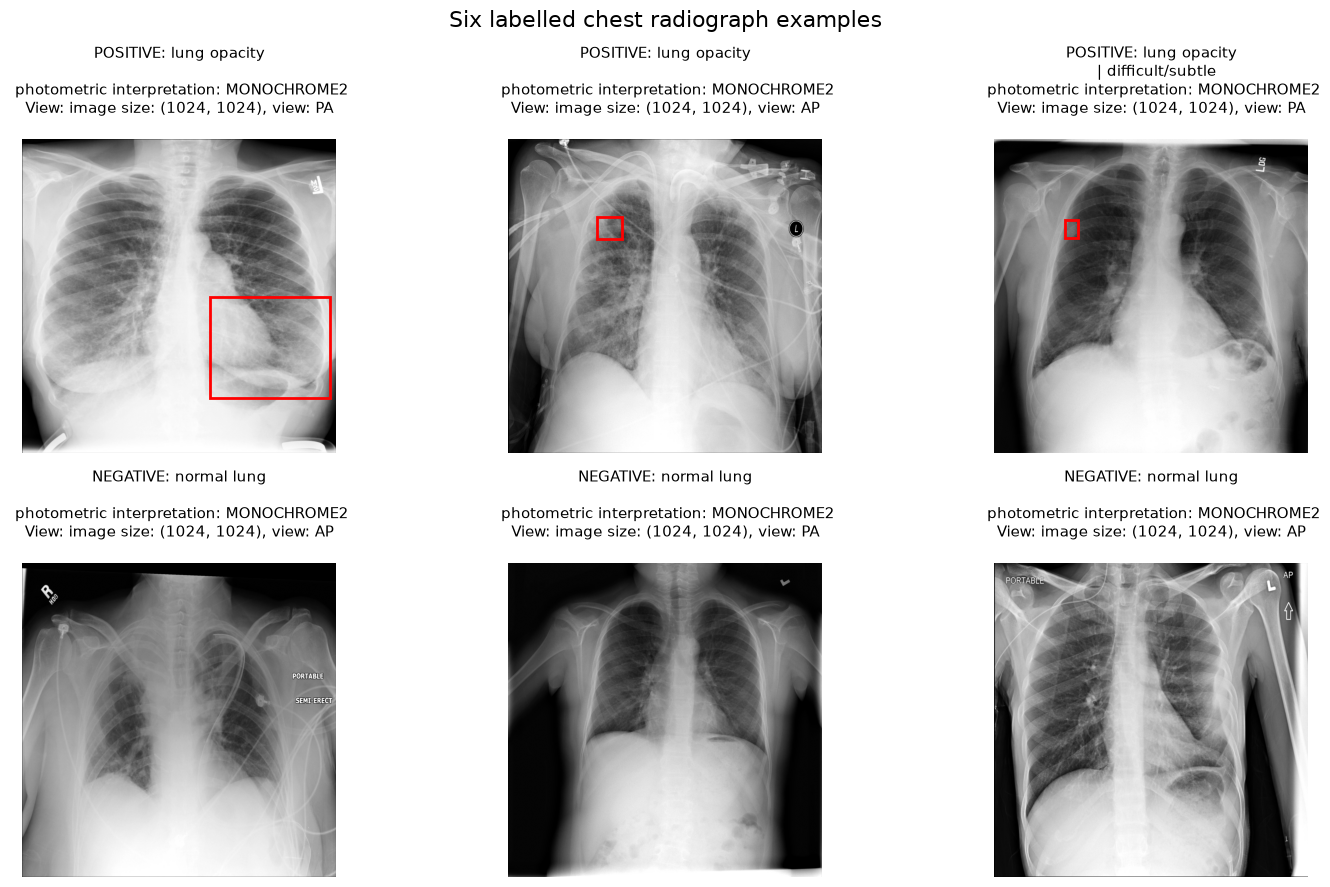

In [34]:

# Match each annotation to its DICOM using the SOPInstanceUID filename stem.
path_by_sop = {path.stem: path for path in dicom_files}
examples = annotations[annotations["SOPInstanceUID"].isin(path_by_sop)].copy()

# Keep two ordinary positive examples and include the smallest annotated opacity
# as a subtle/difficult positive example.
positive = examples[examples["Target"] == 1].copy()
positive["box_area"] = positive["width"].fillna(0) * positive["height"].fillna(0)
difficult_positive = positive.loc[[positive["box_area"].idxmin()]]
other_positive = positive.drop(difficult_positive.index).drop_duplicates("SOPInstanceUID").sort_values("SOPInstanceUID").head(2)

negative = examples[examples["Target"] == 0].sort_values("SOPInstanceUID").head(3)
selected = pd.concat([other_positive, difficult_positive, negative], ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for axis, (_, row) in zip(axes.flat, selected.iterrows()):
    dataset = pydicom.dcmread(path_by_sop[row["SOPInstanceUID"]])
    image = dataset.pixel_array.astype(np.float32)
    image = image * float(getattr(dataset, "RescaleSlope", 1)) + float(getattr(dataset, "RescaleIntercept", 0))

    # Robust contrast makes the radiographs easier to compare in one figure.
    low, high = np.percentile(image, (1, 99))
    if high > low:
        image = np.clip((image - low) / (high - low), 0, 1)
    if getattr(dataset, "PhotometricInterpretation", "") == "MONOCHROME1":
        image = 1 - image

    axis.imshow(image, cmap="gray")
    if row["Target"] == 1 and pd.notna(row["x"]):
        axis.add_patch(plt.Rectangle(
            (row["x"], row["y"]), row["width"], row["height"],
            fill=False, edgecolor="red", linewidth=2
        ))
        difficult = row["SOPInstanceUID"] == difficult_positive.iloc[0]["SOPInstanceUID"]
        suffix = " | difficult/subtle" if difficult else ""
    else:
        suffix = ""
    label = "POSITIVE: lung opacity" if row["Target"] == 1 else "NEGATIVE: normal lung"
    photometric = getattr(dataset, "PhotometricInterpretation", "" )
    view = getattr(dataset, "ViewPosition", "Unknown")
    info= f"image size: {image.shape}, view: {view} "
    axis.set_title(f'{label}\n {suffix }\n photometric interpretation: {photometric}\n View: {info}\n' , fontsize=11)
    axis.axis("off")

fig.suptitle("Six labelled chest radiograph examples", fontsize=16)
plt.tight_layout()
plt.show()

***Part B***

In [35]:

splitter1 = GroupShuffleSplit(test_size=.40, n_splits=2, random_state = 7)
split1 = splitter1.split(mapping, groups=mapping['nih_patient_id'])
train_inds, inds = next(split1)
train = mapping.iloc[train_inds]
mix = mapping.iloc[inds]
splitter2 = GroupShuffleSplit(test_size=.50, n_splits=2, random_state = 7)
split2= splitter2.split(mix, groups=mix['nih_patient_id'])
val_ids, test_ids= next(split2)
val = mix.iloc[val_ids]
test = mix.iloc[test_ids] # keeping untouched until final evaluation

display(train.head())
display(val.head())
display(test.head())


,patientId,nih_patient_id,nih_image_id
1,1.2.276.0.7230010.3.1.4.8323329.10002.15178743...,2245,00002245_000.png
2,1.2.276.0.7230010.3.1.4.8323329.10004.15178743...,30355,00030355_000.png
4,1.2.276.0.7230010.3.1.4.8323329.10006.15178743...,4082,00004082_008.png
6,1.2.276.0.7230010.3.1.4.8323329.10008.15178743...,4283,00004283_000.png
7,1.2.276.0.7230010.3.1.4.8323329.10009.15178743...,8151,00008151_001.png


,patientId,nih_patient_id,nih_image_id
0,1.2.276.0.7230010.3.1.4.8323329.10001.15178743...,11683,00011683_018.png
5,1.2.276.0.7230010.3.1.4.8323329.10007.15178743...,15852,00015852_010.png
13,1.2.276.0.7230010.3.1.4.8323329.10015.15178743...,20826,00020826_013.png
17,1.2.276.0.7230010.3.1.4.8323329.10019.15178743...,22925,00022925_002.png
21,1.2.276.0.7230010.3.1.4.8323329.10023.15178743...,21274,00021274_013.png


,patientId,nih_patient_id,nih_image_id
3,1.2.276.0.7230010.3.1.4.8323329.10005.15178743...,14758,00014758_000.png
14,1.2.276.0.7230010.3.1.4.8323329.10016.15178743...,21415,00021415_000.png
16,1.2.276.0.7230010.3.1.4.8323329.10018.15178743...,9365,00009365_003.png
25,1.2.276.0.7230010.3.1.4.8323329.10028.15178743...,19176,00019176_089.png
29,1.2.276.0.7230010.3.1.4.8323329.10033.15178743...,2381,00002381_007.png


In [36]:
assert len(pd.merge(train, val, how= 'inner', on= "nih_patient_id") )==0
assert len(pd.merge(test, val, how= 'inner', on= "nih_patient_id") )==0
assert len(pd.merge(train, test, how= 'inner', on= "nih_patient_id") )==0
print("All patient-identifier sets are disjoint.")

All patient-identifier sets are disjoint.


In [37]:

mapping_with_labels = mapping.merge(exam_labels, on="patientId", how="left", validate="one_to_one")
assert mapping_with_labels["Target"].notna().all(), "Some examinations have no label"
train_report = mapping_with_labels.loc[train.index]
val_report = mapping_with_labels.loc[val.index]
test_report = mapping_with_labels.loc[test.index]

display(train_report)
display(val_report)
display(test_report)

print(f"Training set size: {len(train_report)}, positive cases: {(train_report["Target"]==1).sum()}, Proportion: {(train_report["Target"]).mean()}")
print(f"Validation set size: {len(val_report)}, positive cases: {(val_report["Target"]==1).sum()}, Proportion: {(val_report["Target"]).mean()}")
print(f"Test set size: {len(test_report)}, positive cases: {(test_report["Target"]==1).sum()}, Proportion: {(test_report["Target"]).mean()}")


,patientId,nih_patient_id,nih_image_id,Target
1,1.2.276.0.7230010.3.1.4.8323329.10002.15178743...,2245,00002245_000.png,0
2,1.2.276.0.7230010.3.1.4.8323329.10004.15178743...,30355,00030355_000.png,0
4,1.2.276.0.7230010.3.1.4.8323329.10006.15178743...,4082,00004082_008.png,0
6,1.2.276.0.7230010.3.1.4.8323329.10008.15178743...,4283,00004283_000.png,0
7,1.2.276.0.7230010.3.1.4.8323329.10009.15178743...,8151,00008151_001.png,1
...,...,...,...,...
25672,1.2.276.0.7230010.3.1.4.8323329.9987.151787434...,22899,00022899_013.png,1
25673,1.2.276.0.7230010.3.1.4.8323329.9988.151787434...,17504,00017504_045.png,1
25674,1.2.276.0.7230010.3.1.4.8323329.9989.151787434...,7076,00007076_003.png,1
25675,1.2.276.0.7230010.3.1.4.8323329.9990.151787434...,26099,00026099_002.png,1


,patientId,nih_patient_id,nih_image_id,Target
0,1.2.276.0.7230010.3.1.4.8323329.10001.15178743...,11683,00011683_018.png,0
5,1.2.276.0.7230010.3.1.4.8323329.10007.15178743...,15852,00015852_010.png,0
13,1.2.276.0.7230010.3.1.4.8323329.10015.15178743...,20826,00020826_013.png,0
17,1.2.276.0.7230010.3.1.4.8323329.10019.15178743...,22925,00022925_002.png,0
21,1.2.276.0.7230010.3.1.4.8323329.10023.15178743...,21274,00021274_013.png,0
...,...,...,...,...
25670,1.2.276.0.7230010.3.1.4.8323329.9985.151787434...,30547,00030547_003.png,0
25676,1.2.276.0.7230010.3.1.4.8323329.9991.151787434...,2049,00002049_001.png,0
25677,1.2.276.0.7230010.3.1.4.8323329.9992.151787434...,2275,00002275_006.png,1
25679,1.2.276.0.7230010.3.1.4.8323329.9995.151787434...,24126,00024126_000.png,0


,patientId,nih_patient_id,nih_image_id,Target
3,1.2.276.0.7230010.3.1.4.8323329.10005.15178743...,14758,00014758_000.png,0
14,1.2.276.0.7230010.3.1.4.8323329.10016.15178743...,21415,00021415_000.png,0
16,1.2.276.0.7230010.3.1.4.8323329.10018.15178743...,9365,00009365_003.png,0
25,1.2.276.0.7230010.3.1.4.8323329.10028.15178743...,19176,00019176_089.png,1
29,1.2.276.0.7230010.3.1.4.8323329.10033.15178743...,2381,00002381_007.png,1
...,...,...,...,...
25653,1.2.276.0.7230010.3.1.4.8323329.9966.151787434...,7718,00007718_004.png,0
25671,1.2.276.0.7230010.3.1.4.8323329.9986.151787434...,30675,00030675_000.png,0
25678,1.2.276.0.7230010.3.1.4.8323329.9993.151787434...,10979,00010979_000.png,0
25682,1.2.276.0.7230010.3.1.4.8323329.9998.151787434...,12008,00012008_000.png,0


Training set size: 15278, positive cases: 3380, Proportion: 0.2212331456996989
Validation set size: 5250, positive cases: 1172, Proportion: 0.22323809523809524
Test set size: 5156, positive cases: 1107, Proportion: 0.21470131885182311


One of the potential leakage route is duplicate radiographs appearing under different anonymised identifiers or across different sites. Patient-level grouping would not detect this if the same image had been re-exported with a different patient ID.
To test for it, calculate a perceptual hash for every image, such as "imagehash.phash", after standardising size and orientation. Compare hashes between training, validation, and test sets. Any exact or near matches across splits should be investigated and assigned to only one split. For a stronger test, compare image embeddings and manually inspect highly similar cross-split pairs.

***Part C***

In [38]:

IMAGE_SIZE = (224, 224)


def dicom_to_tensor(path, image_size=IMAGE_SIZE):
    """Read one DICOM and return a normalized grayscale tensor [1, H, W]."""
    dataset = pydicom.dcmread(path)
    image = dataset.pixel_array.astype(np.float32)

    # Convert stored pixel values to modality values when metadata is present.
    slope = float(getattr(dataset, "RescaleSlope", 1))
    intercept = float(getattr(dataset, "RescaleIntercept", 0))
    image = image * slope + intercept

    # Make MONOCHROME1 and MONOCHROME2 display in the same direction.
    if getattr(dataset, "PhotometricInterpretation", "") == "MONOCHROME1":
        image = image.max() - image

    # Per-image robust scaling reduces scanner exposure extremes.
    low, high = np.percentile(image, (1, 99))
    if high > low:
        image = np.clip((image - low) / (high - low), 0, 1)
    else:
        image = np.zeros_like(image)

    image_tensor = torch.from_numpy(image).unsqueeze(0)
    return resize(image_tensor, image_size, antialias=True).float()


def training_augmentation(image):
    """Apply label-preserving augmentation to a normalized [1, H, W] tensor."""
    height, width = image.shape[-2:]
    angle = float(torch.empty(1).uniform_(-5, 5).item())
    max_dx = int(width * 0.05)
    max_dy = int(height * 0.05)
    translate = [
        int(torch.randint(-max_dx, max_dx + 1, (1,)).item()),
        int(torch.randint(-max_dy, max_dy + 1, (1,)).item()),
    ]
    image = affine(image, angle=angle, translate=translate, scale=1.0, shear=[0.0, 0.0],fill=[0.0] )
    contrast_factor = float(torch.empty(1).uniform_(0.90, 1.10).item())
    return adjust_contrast(image, contrast_factor).clamp(0, 1)


class DICOMDataset(Dataset):
    """Load DICOM images on demand, with augmentation only when requested."""

    def __init__(self, paths, transform=None):
        self.paths = list(paths)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        image = dicom_to_tensor(self.paths[index])
        if self.transform is not None:
            image = self.transform(image)
        return image


# Use this dataset only for training. Validation and test datasets must omit transform.
training_dataset = DICOMDataset(dicom_files, transform=training_augmentation)
evaluation_dataset = DICOMDataset(dicom_files)

original_image = evaluation_dataset[0]
augmented_image = training_dataset[0]

print("Training tensor shape:", tuple(augmented_image.shape))
print("Training intensity range:", float(augmented_image.min()), "to", float(augmented_image.max()))

Training tensor shape: (1, 224, 224)
Training intensity range: 0.0 to 1.0


What training-only augmentation did to original image:

- Small rotation up to 5 degrees: models minor positioning differences while preserving the chest and opacity label.
- Small translation up to 5%: models centering and detector-cropping variation without changing anatomy.
- Mild contrast adjustment (0.90 to 1.10): models exposure and acquisition variation while retaining opacity patterns.
- No horizontal flip: left/right anatomy, tubes, and other devices can be clinically meaningful, so flipping could create unrealistic examples.
The validation and test datasets use no augmentation only training set 

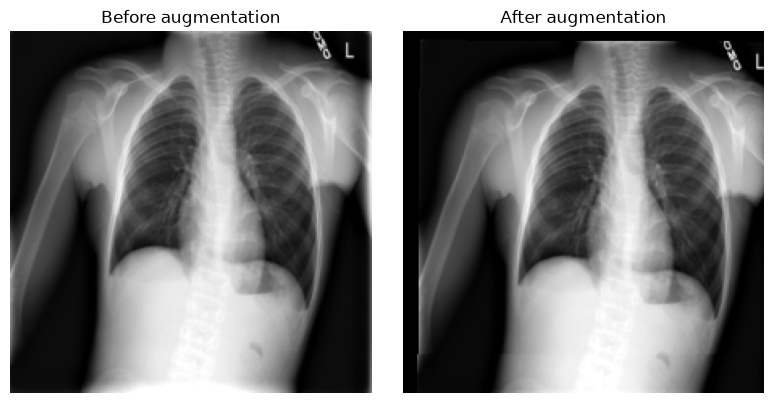

Tensor shape: (1, 224, 224)
Shared intensity scale: [0, 1]


In [39]:
torch.manual_seed(7)
original_image = evaluation_dataset[0]
augmented_image = training_augmentation(original_image.clone())

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(original_image.squeeze(0), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Before augmentation")
axes[1].imshow(augmented_image.squeeze(0), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("After augmentation")

for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()
print("Tensor shape:", tuple(original_image.shape))
print("Shared intensity scale: [0, 1]")

### Class-imbalance comparison

The positive class is handled with `BCEWithLogitsLoss(pos_weight=negative_count / positive_count)`. The unweighted run uses `pos_weight=1`, while the weighted run uses the training-set ratio only. Both runs use the same patient-disjoint splits, model, seed, optimizer, and number of epochs; validation and test data are never rebalanced or augmented.

In [40]:
# Join labels to the mapping and build paths from the supplied patientId values.
def make_labeled_dataset(frame, augment=False):
    paths = [path_by_sop[patient_id] for patient_id in frame["patientId"]]
    labels = frame["Target"].astype(np.float32).to_numpy()

    class LabeledDICOMDataset(Dataset):
        def __len__(self):
            return len(paths)

        def __getitem__(self, index):
            image = dicom_to_tensor(paths[index])
            if augment:
                image = training_augmentation(image)
            return image, torch.tensor(labels[index], dtype=torch.float32)

    return LabeledDICOMDataset()


train_frame = mapping_with_labels.loc[train.index].reset_index(drop=True)
val_frame = mapping_with_labels.loc[val.index].reset_index(drop=True)
test_frame = mapping_with_labels.loc[test.index].reset_index(drop=True)

train_dataset = make_labeled_dataset(train_frame, augment=True)
val_dataset = make_labeled_dataset(val_frame, augment=False)
test_dataset = make_labeled_dataset(test_frame, augment=False)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

positive_count = int(train_frame["Target"].sum())
negative_count = len(train_frame) - positive_count
positive_weight = negative_count / positive_count
print(f"Training positives: {positive_count}")
print(f"Training negatives: {negative_count}")
print(f"Weighted-loss pos_weight: {positive_weight:.3f}")

Training positives: 3380
Training negatives: 11898
Weighted-loss pos_weight: 3.520


The results for this dataset is:
- Training positives: 3380
- Training negatives: 11898
- Weighted-loss pos_weight: 3.520

This means a positive example receives approximately 3.52 times more loss than a negative example, encouraging the model to pay more attention to lung-opacity cases.

Now I will compare two small identical models, one is weighted and another one is unweighted.
Then evaluate results using metrics like Accuracy, Precision, Recall, F1-score, ROC-AUC, PR-AUC


In [41]:
class TinyOpacityCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(16, 1)

    def forward(self, images):
        return self.classifier(self.features(images).flatten(1)).squeeze(1)


def evaluate_model(model, loader):
    model.eval()
    probabilities = []
    targets = []
    with torch.no_grad():
        for images, labels in loader:
            probabilities.append(torch.sigmoid(model(images)).cpu())
            targets.append(labels.cpu())

    probabilities = torch.cat(probabilities).numpy()
    targets = torch.cat(targets).numpy().astype(int)
    predictions = (probabilities >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(targets, predictions),
        "precision": precision_score(targets, predictions, zero_division=0),
        "recall": recall_score(targets, predictions, zero_division=0),
        "f1": f1_score(targets, predictions, zero_division=0),
        "roc_auc": roc_auc_score(targets, probabilities),
        "pr_auc": average_precision_score(targets, probabilities),
    }

def train_and_evaluate(pos_weight, epochs=1, seed=7):
    torch.manual_seed(seed)
    model = TinyOpacityCNN()
    loss_function = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(float(pos_weight)))
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            optimizer.zero_grad()
            loss = loss_function(model(images), labels)
            loss.backward()
            optimizer.step()

    return evaluate_model(model, val_loader)   # validation only; test set stays untouched


unweighted_val = train_and_evaluate(pos_weight=1.0)
weighted_val = train_and_evaluate(pos_weight=positive_weight)

comparison = pd.DataFrame([
    {"run": "Unweighted", **unweighted_val},
    {"run": "Weighted loss", **weighted_val},
])
comparison["recall_change_vs_unweighted"] = comparison["recall"] - comparison["recall"].iloc[0]
display(comparison.round(3))

,run,accuracy,precision,recall,f1,roc_auc,pr_auc,recall_change_vs_unweighted
0,Unweighted,0.777,0.000,0.000,0.000,0.474,0.217,0.000
1,Weighted loss,0.559,0.236,0.438,0.307,0.531,0.229,0.438


As a result, weighted loss improves precision, positive-class recall, ROC-AUC and F1-score, because missing positive opacity cases is penalised more heavily. Accuracy may decrease because the model produce more positive predictions. ROC-AUC and PR-AUC show whether ranking quality changes independently of the chosen 0.5 threshold.

***Pard D***

In [42]:
# Trivial baseline

majority_class = int(train_frame["Target"].mode()[0])
majority_predictions = np.full(len(test_frame), majority_class)
majority_targets = test_frame["Target"].to_numpy()
print("Majority class:", majority_class)
print("Majority baseline test accuracy:", accuracy_score(majority_targets, majority_predictions))
print("Majority baseline test precision:", precision_score(majority_targets, majority_predictions, zero_division=0))
print("Majority baseline test recall:", recall_score(majority_targets, majority_predictions, zero_division=0))
print("Majority baseline test F1:", f1_score(majority_targets, majority_predictions, zero_division=0))

# Six image-summary features: mean, standard deviation, 10th percentile,
# median, 90th percentile, and fraction of pixels above the image mean.
def extract_features(image):
    image = image.squeeze(0).numpy()
    mean_value = image.mean()
    return [ mean_value, image.std(), np.percentile(image, 10), np.percentile(image, 50), np.percentile(image, 90), (image > mean_value).mean(),]


def make_feature_data(frame):
    features = []
    labels = []
    for patient_id, target in zip(frame["patientId"], frame["Target"]):
        features.append(extract_features(dicom_to_tensor(path_by_patient[patient_id])))
        labels.append(target)
    return torch.tensor(features, dtype=torch.float32), torch.tensor(labels, dtype=torch.float32)


path_by_patient = {path.stem: path for path in dicom_files}
x_train, y_train = make_feature_data(train_frame)
x_val, y_val = make_feature_data(val_frame)
x_test, y_test = make_feature_data(test_frame)
feature_mean = x_train.mean(dim=0)
feature_std = x_train.std(dim=0).clamp_min(1e-6)
x_train = (x_train - feature_mean) / feature_std
x_val = (x_val - feature_mean) / feature_std
x_test = (x_test - feature_mean) / feature_std


class LogisticBaseline(nn.Module):
    def __init__(self, number_of_features):
        super().__init__()
        self.classifier = nn.Linear(number_of_features, 1)

    def forward(self, features):
        return self.classifier(features).squeeze(1)


def train_logistic_model(learning_rate, number_of_epochs):
    torch.manual_seed(7)
    model = LogisticBaseline(x_train.shape[1])
    loss_function = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    for _ in range(number_of_epochs):
        optimizer.zero_grad()
        loss = loss_function(model(x_train), y_train)
        loss.backward()
        optimizer.step()
    return model


def feature_metrics(model, features, targets):
    with torch.no_grad():
        probabilities = torch.sigmoid(model(features)).numpy()
    predictions = (probabilities >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(targets, predictions),
        "precision": precision_score(targets, predictions, zero_division=0),
        "recall": recall_score(targets, predictions, zero_division=0),
        "f1": f1_score(targets, predictions, zero_division=0),
        "roc_auc": roc_auc_score(targets, probabilities),
        "pr_auc": average_precision_score(targets, probabilities),
    }


best_model = None
best_settings = None
best_validation_f1 = -1
for learning_rate in [0.0005, 0.001, 0.01, 0.05]:
    for number_of_epochs in [20, 50, 100]:
        candidate_model = train_logistic_model(learning_rate, number_of_epochs)
        validation_results = feature_metrics(candidate_model, x_val, y_val.numpy())
        print(f"lr={learning_rate}, epochs={number_of_epochs}, validation F1={validation_results['f1']:.3f}")
        if validation_results["f1"] > best_validation_f1:
            best_validation_f1 = validation_results["f1"]
            best_model = candidate_model
            best_settings = (learning_rate, number_of_epochs)

print("Selected settings:", best_settings)
print("Validation metrics:", feature_metrics(best_model, x_val, y_val.numpy()))
print("Final simple PyTorch baseline test metrics:", feature_metrics(best_model, x_test, y_test.numpy()))

Majority class: 0
Majority baseline test accuracy: 0.7852986811481769
Majority baseline test precision: 0.0
Majority baseline test recall: 0.0
Majority baseline test F1: 0.0
lr=0.0005, epochs=20, validation F1=0.279
lr=0.0005, epochs=50, validation F1=0.268
lr=0.0005, epochs=100, validation F1=0.244
lr=0.001, epochs=20, validation F1=0.271
lr=0.001, epochs=50, validation F1=0.240
lr=0.001, epochs=100, validation F1=0.140
lr=0.01, epochs=20, validation F1=0.002
lr=0.01, epochs=50, validation F1=0.002
lr=0.01, epochs=100, validation F1=0.000
lr=0.05, epochs=20, validation F1=0.002
lr=0.05, epochs=50, validation F1=0.000
lr=0.05, epochs=100, validation F1=0.007
Selected settings: (0.0005, 20)
Validation metrics: {'accuracy': 0.6415238095238095, 'precision': 0.25312934631432543, 'recall': 0.310580204778157, 'f1': 0.2789272030651341, 'roc_auc': 0.5361580787276102, 'pr_auc': 0.25390642140399877}
Final simple PyTorch baseline test metrics: {'accuracy': 0.6336307214895268, 'precision': 0.22733

***Part E***

In [ ]:
from torchvision.models import ResNet18_Weights, resnet18

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HEAD_EPOCHS = 3
FINETUNE_EPOCHS = 5
HEAD_LR = 1e-3
BACKBONE_LR = 1e-5
CLASSIFIER_LR = 1e-4
WEIGHT_DECAY = 1e-4
TRAINING_SEEDS = [7, 8, 9]


class GrayResNet(nn.Module):
    """ImageNet-pretrained ResNet18 adapted for one-channel binary classification."""
    def __init__(self):
        super().__init__()
        self.backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        # ResNet18 originally predicts 1,000 ImageNet classes. Use one logit
        # because the target is binary: 0 = normal, 1 = lung opacity.
        self.backbone.fc = nn.Linear(in_features, 1)
        self.register_buffer(
            "imagenet_mean",
            torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1),
        )
        self.register_buffer(
            "imagenet_std",
            torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1),
        )
    def forward(self, x):
        if x.ndim != 4 or x.shape[1] != 1:
            raise ValueError(f"Expected input shape [B, 1, H, W], got {tuple(x.shape)}")

        # Repeat grayscale into RGB because ImageNet weights expect 3 channels.
        x = x.repeat(1, 3, 1, 1)
        x = (x - self.imagenet_mean) / self.imagenet_std
        return self.backbone(x).squeeze(1)


def set_seed(seed):
    """Set all relevant random seeds for a reproducible training run."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def freeze_backbone(model):
    for parameter in model.backbone.parameters():
        parameter.requires_grad = False
    for parameter in model.backbone.fc.parameters():
        parameter.requires_grad = True

def unfreeze_final_block(model):
    for parameter in model.backbone.parameters():
        parameter.requires_grad = False
    for parameter in model.backbone.layer4.parameters():
        parameter.requires_grad = True
    for parameter in model.backbone.fc.parameters():
        parameter.requires_grad = True

def set_frozen_batchnorm_eval(model):
    """Prevent running-statistic updates in frozen ResNet batch-normalisation layers."""
    for module in model.backbone.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()

def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    if training:
        set_frozen_batchnorm_eval(model)

    total_loss = 0.0
    total_examples = 0
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        if training:
            optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        if training:
            loss.backward()
            optimizer.step()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

    return total_loss / total_examples


@torch.inference_mode()
def validation_metrics(model, loader):
    model.eval()
    probabilities = []
    targets = []
    for images, labels in loader:
        logits = model(images.to(DEVICE))
        probabilities.append(torch.sigmoid(logits).cpu())
        targets.append(labels.cpu())

    probabilities = torch.cat(probabilities).numpy()
    targets = torch.cat(targets).numpy().astype(int)
    predictions = (probabilities >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(targets, predictions),
        "precision": precision_score(targets, predictions, zero_division=0),
        "recall": recall_score(targets, predictions, zero_division=0),
        "f1": f1_score(targets, predictions, zero_division=0),
        "roc_auc": roc_auc_score(targets, probabilities),
        "pr_auc": average_precision_score(targets, probabilities),
    }


def train_cnn(seed, weighted_loss=True):
    set_seed(seed)
    model = GrayResNet().to(DEVICE)
    pos_weight = torch.tensor(float(positive_weight), device=DEVICE) if weighted_loss else None
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    history = []

    # Phase 1 with fixed feature extractor, where we train only the new classification head
    freeze_backbone(model)
    head_optimizer = optim.AdamW(
        model.backbone.fc.parameters(), lr=HEAD_LR, weight_decay=WEIGHT_DECAY
    )
    for epoch in range(1, HEAD_EPOCHS + 1):
        train_loss = run_epoch(model, train_loader, criterion, head_optimizer)
        val_loss = run_epoch(model, val_loader, criterion)
        row = {"phase": "fixed_features", "epoch": epoch,
               "train_loss": train_loss, "val_loss": val_loss}
        history.append(row)
        print(f"Seed {seed} | fixed features | epoch {epoch}/{HEAD_EPOCHS} | "
              f"train loss={train_loss:.4f} | val loss={val_loss:.4f}")

    # Phase 2 with fine-tune the final convolutional block and classification head
    unfreeze_final_block(model)
    finetune_optimizer = optim.AdamW(
        [
            {"params": model.backbone.layer4.parameters(), "lr": BACKBONE_LR},
            {"params": model.backbone.fc.parameters(), "lr": CLASSIFIER_LR},
        ],
        weight_decay=WEIGHT_DECAY,
    )
    for epoch in range(1, FINETUNE_EPOCHS + 1):
        train_loss = run_epoch(model, train_loader, criterion, finetune_optimizer)
        val_loss = run_epoch(model, val_loader, criterion)
        row = {"phase": "fine_tune_layer4", "epoch": HEAD_EPOCHS + epoch,
               "train_loss": train_loss, "val_loss": val_loss}
        history.append(row)
        print(f"Seed {seed} | fine-tune layer4 | epoch {epoch}/{FINETUNE_EPOCHS} | "
              f"train loss={train_loss:.4f} | val loss={val_loss:.4f}")

    return model, pd.DataFrame(history)

headline_model, headline_history = train_cnn(seed=TRAINING_SEEDS[0], weighted_loss=True)
headline_validation = validation_metrics(headline_model, val_loader)
print("Headline validation metrics:", headline_validation)

fig, axis = plt.subplots(figsize=(8, 5))
axis.plot(headline_history["epoch"], headline_history["train_loss"], marker="o", label="Training")
axis.plot(headline_history["epoch"], headline_history["val_loss"], marker="o", label="Validation")
axis.axvline(HEAD_EPOCHS + 0.5, color="gray", linestyle="--", label="Start fine-tuning")
axis.set_xlabel("Epoch")
axis.set_ylabel("BCE loss")
axis.set_title("ResNet18 training and validation loss")
axis.legend()
axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

seed_results = []
for seed in TRAINING_SEEDS:
    model, history = train_cnn(seed=seed, weighted_loss=True)
    metrics = validation_metrics(model, val_loader)
    seed_results.append({"seed": seed, **metrics})

seed_results = pd.DataFrame(seed_results)
print("Three-seed validation results:")
display(seed_results.round(3))
print(
    f"Validation PR-AUC: {seed_results['pr_auc'].mean():.3f} "
    f"+/- {seed_results['pr_auc'].std(ddof=1):.3f} "
    f"(mean +/- sample standard deviation)"
)
unweighted_model, unweighted_history = train_cnn(seed=TRAINING_SEEDS[0], weighted_loss=False)
resnet_ablation = pd.DataFrame([
    {"loss": "Weighted BCE (pos_weight = 3.52)", **validation_metrics(headline_model, val_loader)},
    {"loss": "Unweighted BCE", **validation_metrics(unweighted_model, val_loader)},
])
display(resnet_ablation.round(3))



Seed 7 | fixed features | epoch 1/3 | train loss=0.8560 | val loss=0.8266
Seed 7 | fixed features | epoch 2/3 | train loss=0.7890 | val loss=0.8113
Seed 7 | fixed features | epoch 3/3 | train loss=0.7829 | val loss=0.8045
Seed 7 | fine-tune layer4 | epoch 1/5 | train loss=0.7530 | val loss=0.7686
Seed 7 | fine-tune layer4 | epoch 2/5 | train loss=0.7226 | val loss=0.7506


***Part F:***

Test set: 5156 images, positive rate = 0.215


,Predicted 0,Predicted 1
Actual 0 (Normal),3324,725
Actual 1 (Opacity),321,786


accuracy    : 0.797
sensitivity : 0.710
specificity : 0.821
precision   : 0.520
f1          : 0.600


,TN,FP,FN,TP,accuracy,sensitivity,specificity,precision,f1,roc_auc,pr_auc
Trivial baseline (prevalence),4049.0,0.0,1107.0,0.0,0.785,0.000,1.000,0.000,0.000,0.500,0.215
Simple baseline (logistic),2941.0,1108.0,781.0,326.0,0.634,0.294,0.726,0.227,0.257,0.513,0.230
CNN (ResNet18),3324.0,725.0,321.0,786.0,0.797,0.710,0.821,0.520,0.600,0.850,0.614


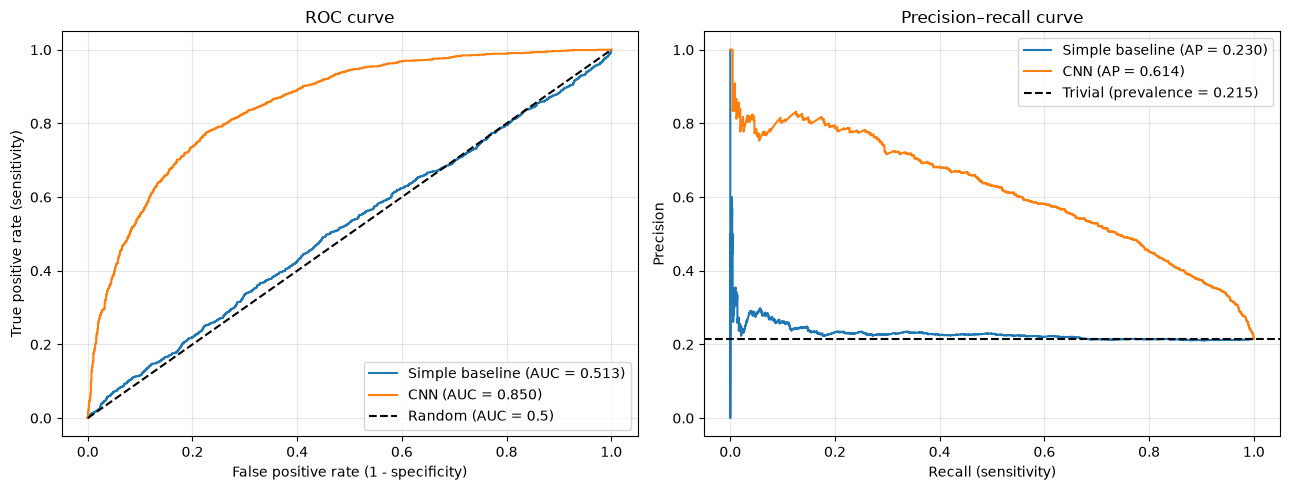

Screening threshold (frozen):        0.2209
High-specificity threshold (frozen): 0.6780


,operating point,split,threshold,TP,FN,FP,TN,sensitivity,specificity,precision,f1
0,Default 0.5,validation,0.500,827,345,750,3328,0.706,0.816,0.524,0.602
1,Default 0.5,test,0.500,786,321,725,3324,0.710,0.821,0.520,0.600
2,Screening,validation,0.221,1055,117,1558,2520,0.900,0.618,0.404,0.557
3,Screening,test,0.221,977,130,1566,2483,0.883,0.613,0.384,0.535
4,High specificity,validation,0.678,634,538,407,3671,0.541,0.900,0.609,0.573
5,High specificity,test,0.678,598,509,379,3670,0.540,0.906,0.612,0.574


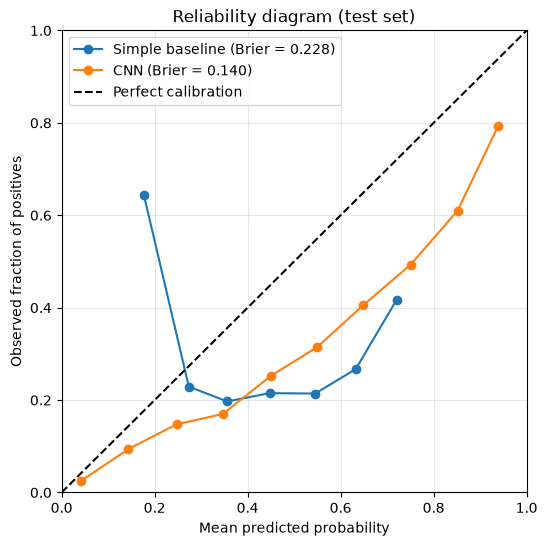

In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

def cnn_probabilities(model, loader):
    model.eval()
    probs = []
    with torch.no_grad():
        for images, _ in loader:
            probs.append(torch.sigmoid(model(images.to(DEVICE))).cpu())
    return torch.cat(probs).numpy()

def logistic_probabilities(model, features):
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(model(features)).numpy()

y_val_true  = val_frame["Target"].to_numpy().astype(int)
y_test_true = test_frame["Target"].to_numpy().astype(int)

#CNN
cnn_val  = cnn_probabilities(headline_model, val_loader)
cnn_test = cnn_probabilities(headline_model, test_loader)

#Simple baseline which is a logistic regression
simple_val  = logistic_probabilities(best_model, x_val)
simple_test = logistic_probabilities(best_model, x_test)

#Trivial baseline where model always predicts the training-set prevalence
prevalence   = train_frame["Target"].mean()
trivial_val  = np.full(len(y_val_true),  prevalence)
trivial_test = np.full(len(y_test_true), prevalence)

print(f"Test set: {len(y_test_true)} images, positive rate = {y_test_true.mean():.3f}")

def evaluate(y_true, probs, threshold=0.5):
    y_pred = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else 0.0
    return {
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "accuracy": (tp + tn) / len(y_true),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "f1": f1,
        "roc_auc": roc_auc_score(y_true, probs),
        "pr_auc": average_precision_score(y_true, probs),
    }

cnn_results = evaluate(y_test_true, cnn_test)

cm = confusion_matrix(y_test_true, (cnn_test >= 0.5).astype(int))
display(pd.DataFrame(cm,
                     index=["Actual 0 (Normal)", "Actual 1 (Opacity)"],
                     columns=["Predicted 0", "Predicted 1"]))

for name in ["accuracy", "sensitivity", "specificity", "precision", "f1"]:
    print(f"{name:12s}: {cnn_results[name]:.3f}")

    comparison_table = pd.DataFrame({
    "Trivial baseline (prevalence)": evaluate(y_test_true, trivial_test),
    "Simple baseline (logistic)":    evaluate(y_test_true, simple_test),
    "CNN (ResNet18)":                evaluate(y_test_true, cnn_test),
}).T
display(comparison_table.round(3))


fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(13, 5))

for name, probs in [("Simple baseline", simple_test), ("CNN", cnn_test)]:
    fpr, tpr, _ = roc_curve(y_test_true, probs)
    ax_roc.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test_true, probs):.3f})")

    prec, rec, _ = precision_recall_curve(y_test_true, probs)
    ax_pr.plot(rec, prec, label=f"{name} (AP = {average_precision_score(y_test_true, probs):.3f})")

ax_roc.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
ax_pr.axhline(y_test_true.mean(), color="k", linestyle="--",
              label=f"Trivial (prevalence = {y_test_true.mean():.3f})")

ax_roc.set(xlabel="False positive rate (1 - specificity)",
           ylabel="True positive rate (sensitivity)", title="ROC curve")
ax_pr.set(xlabel="Recall (sensitivity)", ylabel="Precision", title="Precision–recall curve")
for ax in (ax_roc, ax_pr):
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#For screening wen need highest threshold with validation sensitivity >= 0.90
#For diagnistic we need high specificity lowest threshold with validation specificity >= 0.90
val_fpr, val_tpr, val_thresholds = roc_curve(y_val_true, cnn_val)
val_specificity = 1 - val_fpr

SCREENING_THRESHOLD = float(val_thresholds[np.argmax(val_tpr >= 0.90)])
HIGH_SPEC_THRESHOLD = float(val_thresholds[np.where(val_specificity >= 0.90)[0][-1]])

print(f"Screening threshold (frozen):        {SCREENING_THRESHOLD:.4f}")
print(f"High-specificity threshold (frozen): {HIGH_SPEC_THRESHOLD:.4f}")

rows = []
for name, t in [("Default 0.5", 0.5),
                ("Screening", SCREENING_THRESHOLD),
                ("High specificity", HIGH_SPEC_THRESHOLD)]:
    for split, y, p in [("validation", y_val_true, cnn_val), ("test", y_test_true, cnn_test)]:
        r = evaluate(y, p, t)
        rows.append({"operating point": name, "split": split, "threshold": t,
                     **{k: r[k] for k in ["TP", "FN", "FP", "TN",
                                          "sensitivity", "specificity", "precision", "f1"]}})
display(pd.DataFrame(rows).round(3))

fig, ax = plt.subplots(figsize=(6, 6))
for name, probs in [("Simple baseline", simple_test), ("CNN", cnn_test)]:
    observed, predicted = calibration_curve(y_test_true, probs, n_bins=10, strategy="uniform")
    ax.plot(predicted, observed, marker="o",
            label=f"{name} (Brier = {brier_score_loss(y_test_true, probs):.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set(xlabel="Mean predicted probability", ylabel="Observed fraction of positives",
       title="Reliability diagram (test set)", xlim=(0, 1), ylim=(0, 1))
ax.legend(); ax.grid(alpha=0.3)
plt.show()

**Area under the curves (test set)**

| Model | ROC-AUC | PR-AUC (AP) |
|---|---|---|
| Simple baseline | 0.513 | 0.230 |
| CNN | 0.850 | 0.614 |
| Random / trivial reference | 0.500 | 0.215 |

Regarding the question of which AUC is more informative, I need say that only 21.5% of test images are positive, so the classes are imbalanced. First of all, the ROC curve plots sensitivity against the false positive rate and the false positive rate is divided by the large number of negatives (4,049). This imbalanced dataset therefore moves the curve only a little. The CNN's ROC-AUC of 0.85 looks strong, even though at the 0.5 threshold almost half of its positive predictions are wrong. While, the precision–recall curve ignores true negatives and focuses on the positive class. Precision directly shows the false-alarm burden, and the baseline is the prevalence, not 0.5. The PR curve also shows that precision falls from about 0.8 to under 0.4 as recall approaches 0.9, a trade-off the ROC curve hides.
As a result, the **PR curve is therefore more informative** here. It reflects the imbalance and answers the clinical question: "when the model flags an image, how often is it really opacity?", but the ROC curve is still useful because it does not depend on prevalence, which makes it easier to compare across datasets.


For the calibration results:

- CNN: every point lies below the diagonal, so the model is **over-confident** because its predicted probabilities are higher than the true risk. For example, images given about 0.75 are positive only about 49% of the time, and images given about 0.55 only about 31% of the time. This is expected, because training used a weighted loss where "pos_weight" ≈ 3.5 that pushes probabilities towards the positive class. Its Brier score is still better than always predicting the prevalence.
- Simple baseline:the curve is almost flat around 0.2. Whatever probability it outputs, the observed positive rate barely changes, which confirms it has almost no useful information. Its Brier score is even worse than the trivial baseline. The isolated point at about 0.18 → 0.64 probably comes from a bin with very few images and should not be over-interpreted.

**Discrimination and calibrationdifferences:**

- Discrimination is the model's ability to rank patients, giving higher scores to positive cases than to negative ones ranking them higher. It is measured by ROC-AUC and PR-AUC and it does not depend on the actual probability values, only on their order.
- Calibration is whether the predicted probabilities match observed frequencies: of all patients given 0.3, about 30% should truly have opacity. It is shown by the reliability diagram and the Brier score.

The CNN shows that these are different properties: it discriminates well (ROC-AUC 0.85) but is poorly calibrated because it over-estimates risk. This does not affect threshold-based decisions, because the thresholds in F.4 were chosen on validation for these specific scores. It does mean the raw output should not be reported to a clinician as "the probability of pneumonia". That would need recalibration first, for example Platt scaling or isotonic regression fitted on the validation set.

***Part G***

outcome
TN    3324
TP     786
FP     725
FN     321
Name: count, dtype: int64


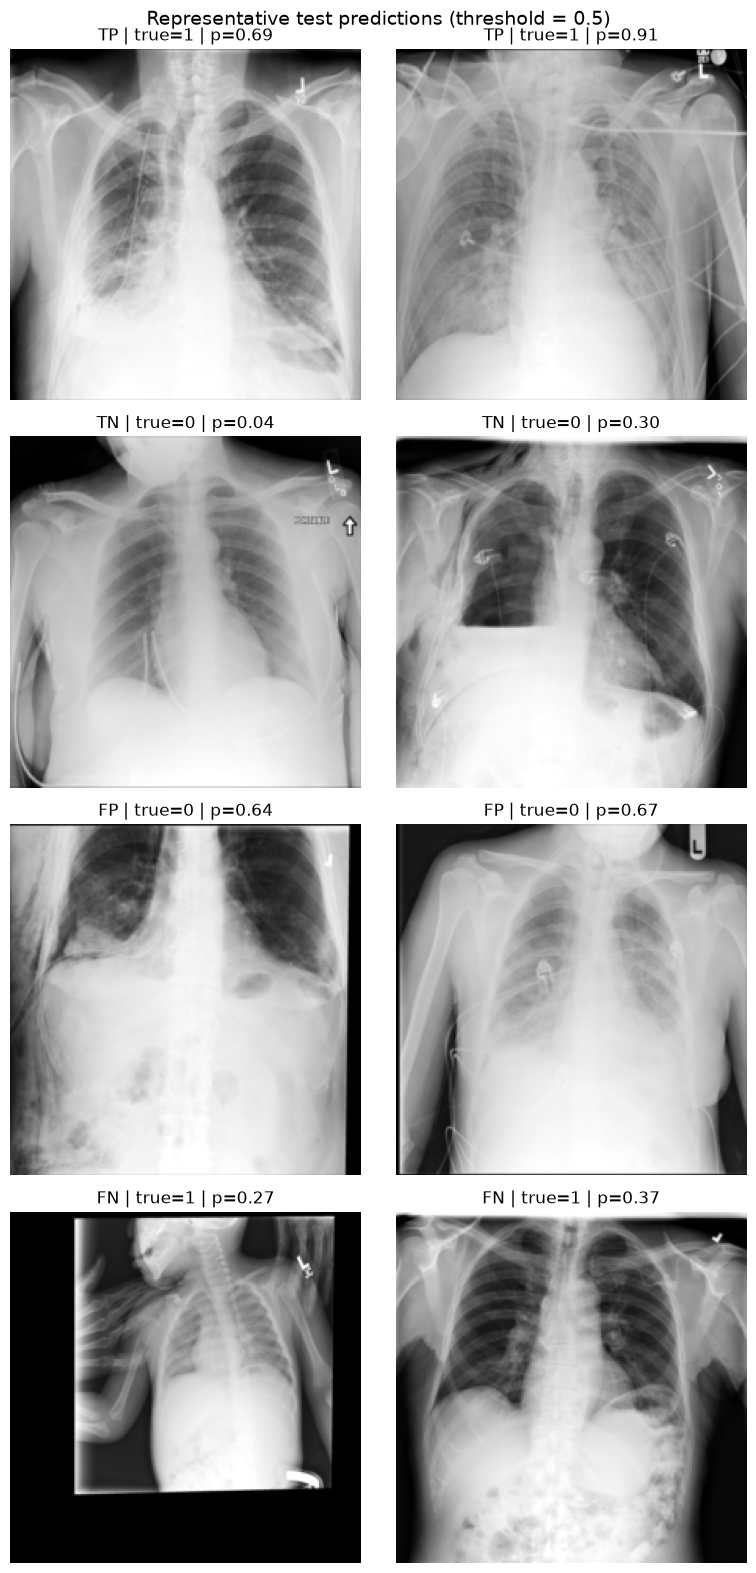

,patientId,Target,probability,prediction,outcome,view,sex,age,rows,cols
0,1.2.276.0.7230010.3.1.4.8323329.10005.15178743...,0,0.242629,0,TN,PA,M,59,1024,1024
1,1.2.276.0.7230010.3.1.4.8323329.10016.15178743...,0,0.040365,0,TN,PA,M,35,1024,1024
2,1.2.276.0.7230010.3.1.4.8323329.10018.15178743...,0,0.817165,1,FP,AP,M,57,1024,1024
3,1.2.276.0.7230010.3.1.4.8323329.10028.15178743...,1,0.697697,1,TP,AP,F,66,1024,1024
4,1.2.276.0.7230010.3.1.4.8323329.10033.15178743...,1,0.429495,0,FN,AP,F,69,1024,1024



Performance by view (test set, threshold = 0.5)


,view,n,n_positive,prevalence,sensitivity,specificity,precision,f1,roc_auc,pr_auc
0,AP,2387,870,0.364,0.814,0.606,0.542,0.651,0.787,0.669
1,PA,2769,237,0.086,0.329,0.950,0.380,0.353,0.810,0.334



Performance by sex (test set, threshold = 0.5)


,sex,n,n_positive,prevalence,sensitivity,specificity,precision,f1,roc_auc,pr_auc
0,F,2329,493,0.212,0.71,0.841,0.545,0.617,0.856,0.651
1,M,2827,614,0.217,0.71,0.804,0.502,0.588,0.845,0.593


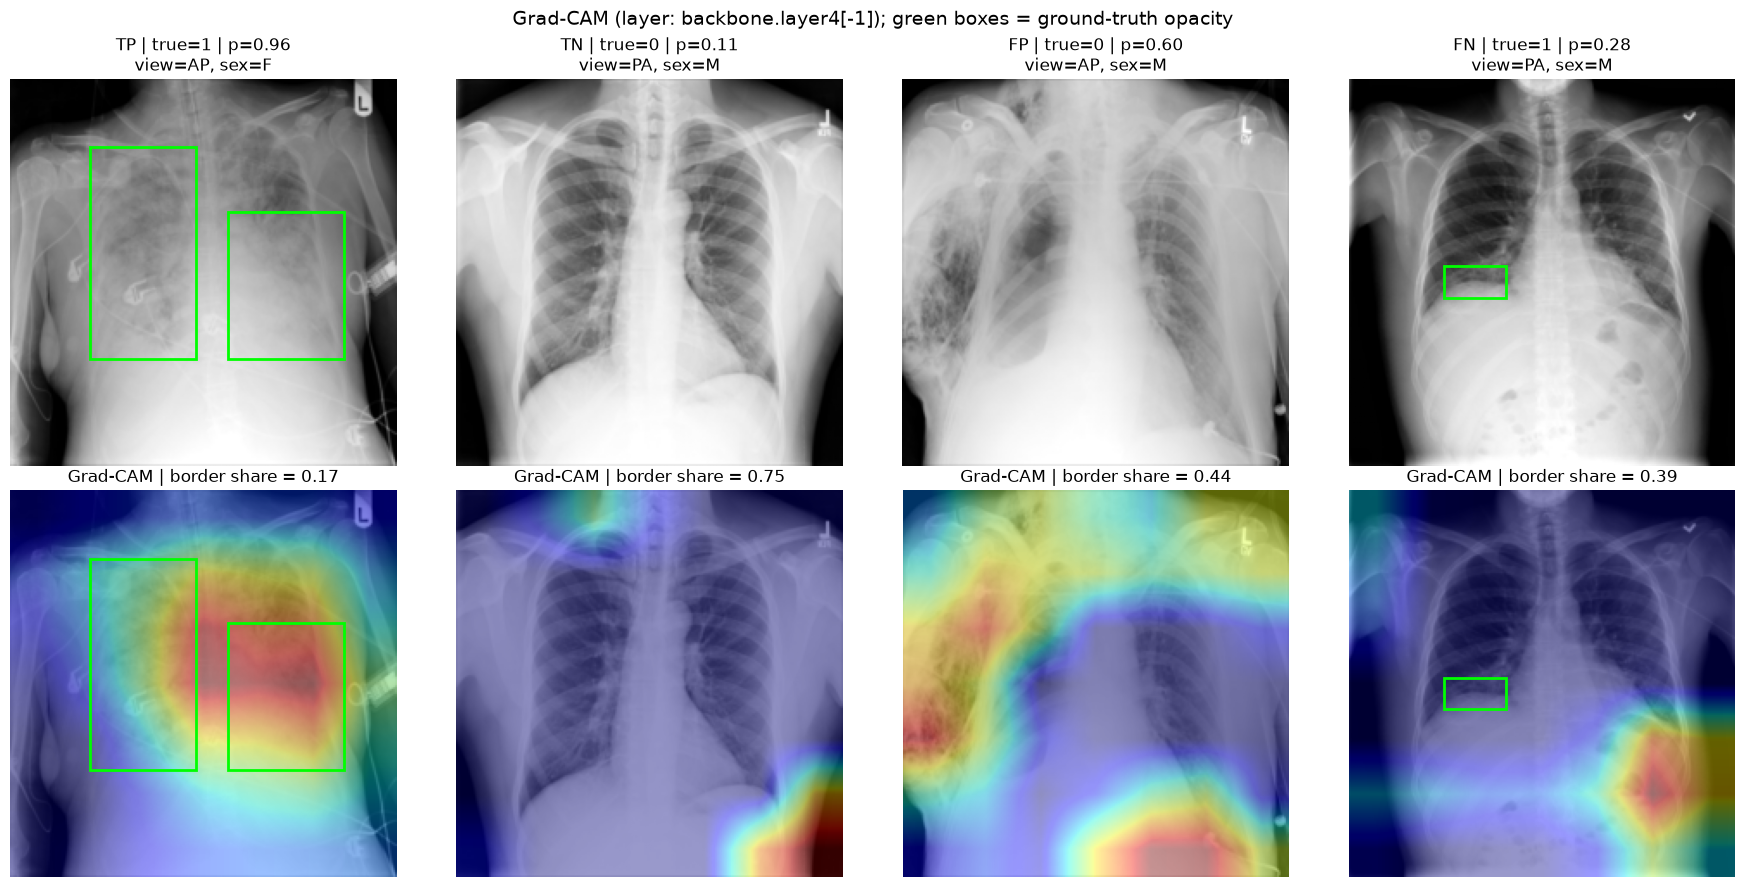

In [ ]:
THRESHOLD = 0.5 
results = test_frame[["patientId", "Target"]].copy()
results["probability"] = cnn_test
results["prediction"] = (cnn_test >= THRESHOLD).astype(int)

def outcome(row):
    if row["Target"] == 1 and row["prediction"] == 1: return "TP"
    if row["Target"] == 0 and row["prediction"] == 0: return "TN"
    if row["Target"] == 0 and row["prediction"] == 1: return "FP"
    return "FN"

results["outcome"] = results.apply(outcome, axis=1)
print(results["outcome"].value_counts())

rng = np.random.default_rng(7)
examples_per_group = 2
fig, axes = plt.subplots(4, examples_per_group, figsize=(4 * examples_per_group, 16))
for r, group in enumerate(["TP", "TN", "FP", "FN"]):
    group_rows = results[results["outcome"] == group]
    picks = group_rows.iloc[rng.choice(len(group_rows), examples_per_group, replace=False)]
    for c, (_, row) in enumerate(picks.iterrows()):
        image = dicom_to_tensor(path_by_sop[row["patientId"]]).squeeze(0)
        ax = axes[r, c]
        ax.imshow(image, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"{group} | true={row['Target']} | p={row['probability']:.2f}")
        ax.axis("off")
plt.suptitle(f"Representative test predictions (threshold = {THRESHOLD})", fontsize=14)
plt.tight_layout()
plt.show()

def read_header(patient_id):
    ds = pydicom.dcmread(path_by_sop[patient_id], stop_before_pixels=True)  # header only, fast
    return {
        "patientId": patient_id,
        "view": getattr(ds, "ViewPosition", "Unknown"),
        "sex": getattr(ds, "PatientSex", "Unknown"),
        "age": pd.to_numeric(getattr(ds, "PatientAge", np.nan), errors="coerce"),
        "rows": int(ds.Rows),
        "cols": int(ds.Columns),
    }

headers = pd.DataFrame([read_header(pid) for pid in results["patientId"]])
results = results.merge(headers, on="patientId")
display(results.head())

def subgroup_table(column):
    rows = []
    for value, group in results.groupby(column, observed=True):
        y, p = group["Target"].to_numpy(), group["probability"].to_numpy()
        m = evaluate(y, p, THRESHOLD) if len(np.unique(y)) == 2 else None   # AUC needs both classes
        rows.append({
            column: value,
            "n": len(group),
            "n_positive": int(y.sum()),
            "prevalence": y.mean(),
            "sensitivity": m["sensitivity"] if m else np.nan,
            "specificity": m["specificity"] if m else np.nan,
            "precision": m["precision"] if m else np.nan,
            "f1": m["f1"] if m else np.nan,
            "roc_auc": m["roc_auc"] if m else np.nan,
            "pr_auc": m["pr_auc"] if m else np.nan,
        })
    return pd.DataFrame(rows)

for column in ["view", "sex"]:
    print(f"\nPerformance by {column} (test set, threshold = {THRESHOLD})")
    display(subgroup_table(column).round(3))

import torch.nn.functional as F

target_layer = headline_model.backbone.layer4[-1]
saved = {}

def forward_hook(module, inputs, output):
    saved["activation"] = output
    output.register_hook(lambda grad: saved.__setitem__("gradient", grad))

hook = target_layer.register_forward_hook(forward_hook)

def grad_cam(image):
    """Return a [224, 224] heatmap in [0, 1] and the predicted probability."""
    headline_model.eval()
    x = image.unsqueeze(0).to(DEVICE).requires_grad_(True)
    logit = headline_model(x)          
    headline_model.zero_grad()
    logit.backward()

    activation = saved["activation"][0]            
    gradient = saved["gradient"][0]               
    weights = gradient.mean(dim=(1, 2))         
    cam = F.relu((weights[:, None, None] * activation).sum(0))
    cam = F.interpolate(cam[None, None], size=image.shape[-2:], mode="bilinear",
                        align_corners=False)[0, 0]
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam.detach().cpu().numpy(), torch.sigmoid(logit).item()

def border_fraction(cam, margin=0.10):
    """Share of the heatmap that falls in the outer 10% frame of the image."""
    h, w = cam.shape
    mh, mw = int(h * margin), int(w * margin)
    centre = cam[mh:h - mh, mw:w - mw].sum()
    return 1 - centre / (cam.sum() + 1e-8)


rng = np.random.default_rng(7)
cam_cases = [results[results["outcome"] == g].sample(1, random_state=7).iloc[0]
             for g in ["TP", "TN", "FP", "FN"]]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for c, row in enumerate(cam_cases):
    image = dicom_to_tensor(path_by_sop[row["patientId"]])
    cam, prob = grad_cam(image)

    axes[0, c].imshow(image.squeeze(0), cmap="gray", vmin=0, vmax=1)
    axes[0, c].set_title(f"{row['outcome']} | true={row['Target']} | p={prob:.2f}\n"
                         f"view={row['view']}, sex={row['sex']}")
    axes[1, c].imshow(image.squeeze(0), cmap="gray", vmin=0, vmax=1)
    axes[1, c].imshow(cam, cmap="jet", alpha=0.4)
    axes[1, c].set_title(f"Grad-CAM | border share = {border_fraction(cam):.2f}")

    boxes = annotations[(annotations["patientId"] == row["patientId"]) & annotations["x"].notna()]
    sx, sy = 224 / row["cols"], 224 / row["rows"]
    for _, b in boxes.iterrows():
        for ax in axes[:, c]:
            ax.add_patch(plt.Rectangle((b["x"] * sx, b["y"] * sy), b["width"] * sx,
                                       b["height"] * sy, fill=False, edgecolor="lime", linewidth=2))
for ax in axes.flat:
    ax.axis("off")
plt.suptitle("Grad-CAM (layer: backbone.layer4[-1]); green boxes = ground-truth opacity", fontsize=14)
plt.tight_layout()
plt.show()

hook.remove()

***Bonus question 2***


Border mask:  14832 pixels (29.6% of image)
Control mask: 14880 pixels (29.7% of image)


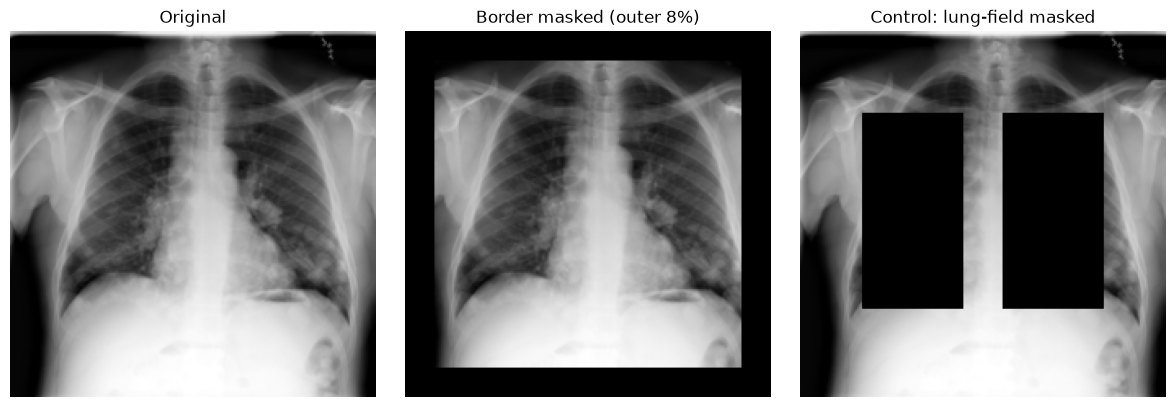

,mean Δp,median Δp,mean |Δp|,95th pct |Δp|,% with |Δp| > 0.10,predictions flipped at 0.5,mean Δp (true positives),mean Δp (true negatives)
Border mask,0.060,0.042,0.082,0.240,30.974,467.0,0.044,0.065
Control (lung) mask,-0.031,0.056,0.233,0.559,77.192,1441.0,-0.303,0.043


Wilcoxon signed-rank test on |Δp| (border vs control): p = 0.00e+00
Images where border |Δp| > control |Δp|: 22.1%


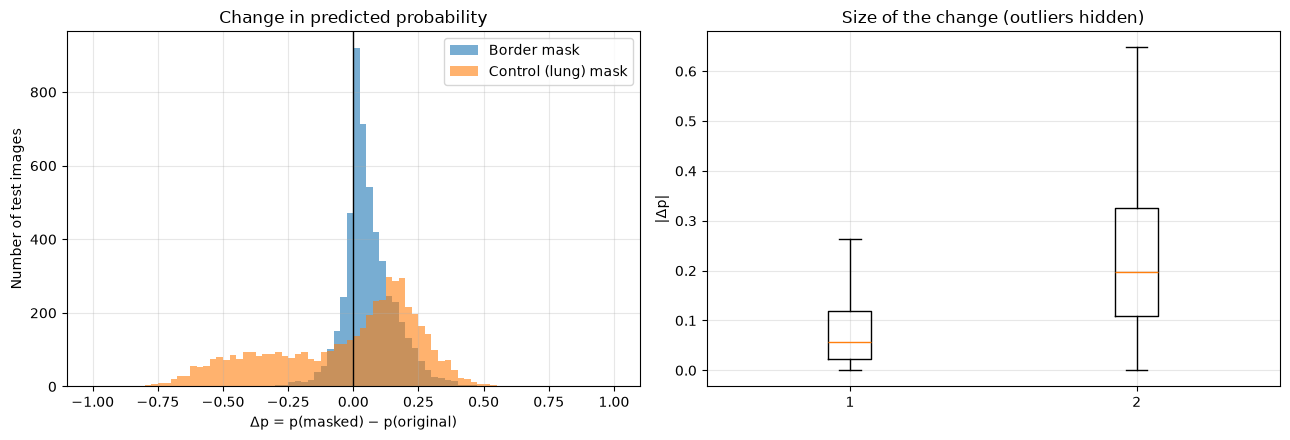

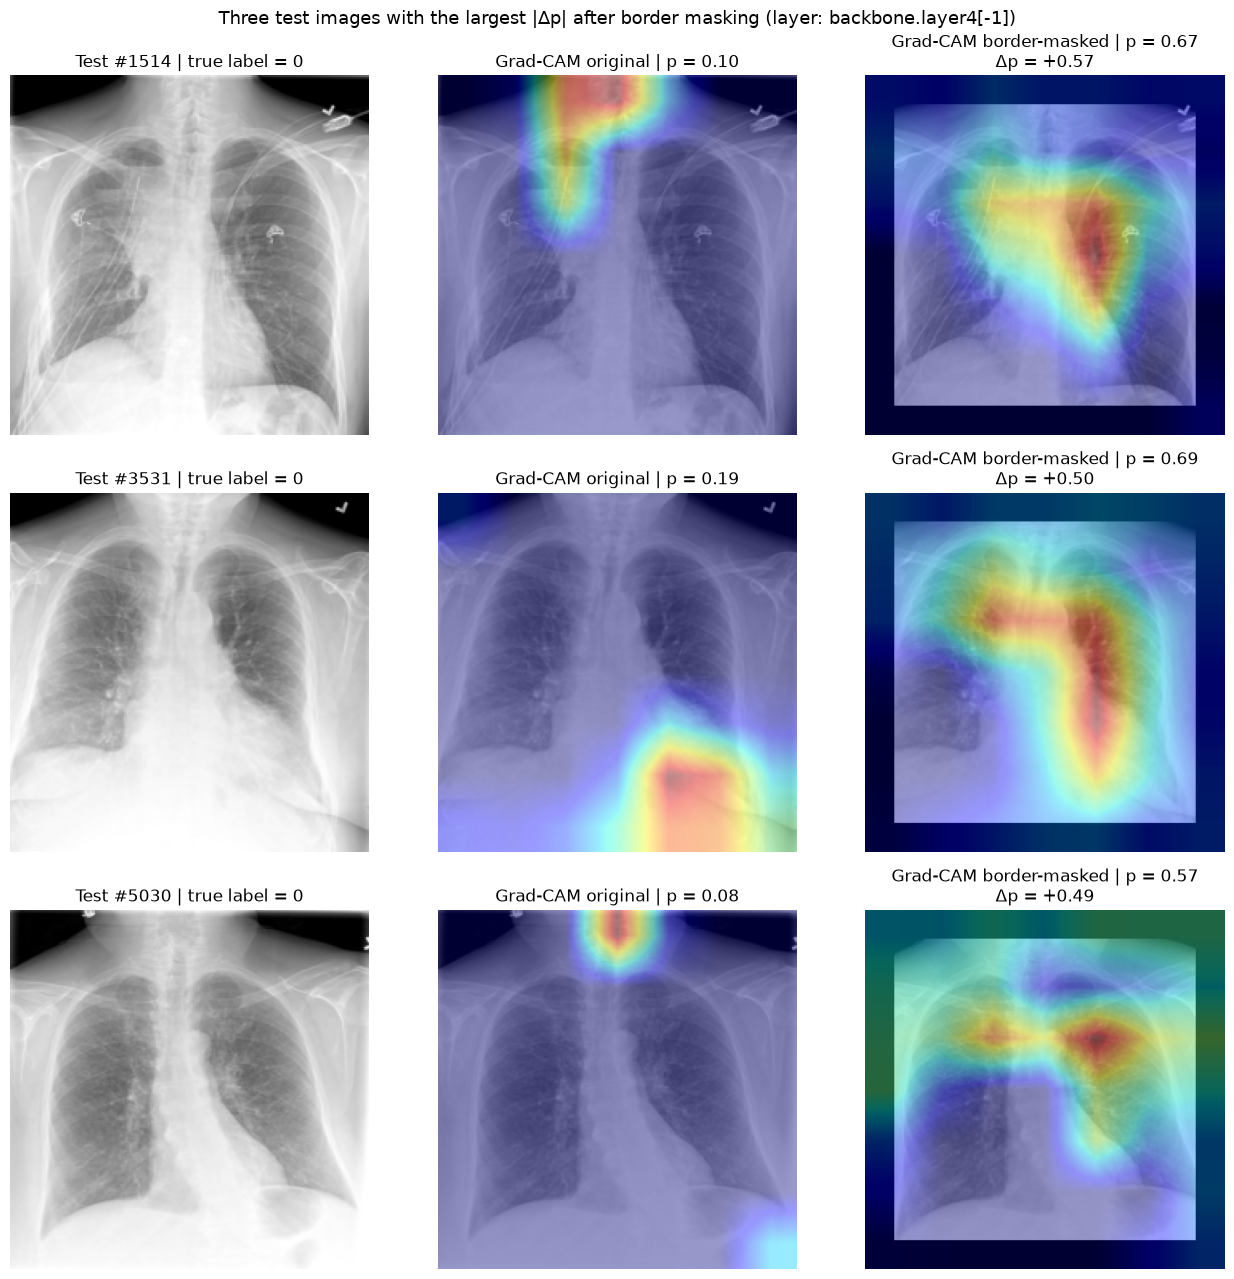

In [ ]:
IMG = 224
BORDER_FRACTION = 0.08
m = round(BORDER_FRACTION * IMG)        

#Border mask of image which is an outer 8% of width and height (True = pixel is masked)
border_mask = torch.ones(IMG, IMG, dtype=torch.bool)
border_mask[m:IMG - m, m:IMG - m] = False

#control mask which is two rectangles inside the lung fields (one per lung).
control_mask = torch.zeros(IMG, IMG, dtype=torch.bool)
control_mask[50:170, 38:100] = True       
control_mask[50:170, 124:186] = True   

print(f"Border mask:  {border_mask.sum().item()} pixels ({border_mask.float().mean():.1%} of image)")
print(f"Control mask: {control_mask.sum().item()} pixels ({control_mask.float().mean():.1%} of image)")
# to check that two regions dont overlap
assert not (border_mask & control_mask).any()   

FILL_VALUE = 0.0  

def apply_mask(images, mask):
    """Deterministic transform: set masked pixels to FILL_VALUE. images: [B, 1, H, W]."""
    out = images.clone()
    out[:, :, mask] = FILL_VALUE
    return out

example = test_dataset[0][0]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(axes,
                          [example, apply_mask(example[None], border_mask)[0], apply_mask(example[None], control_mask)[0]],
                          ["Original", "Border masked (outer 8%)", "Control: lung-field masked"]):
    ax.imshow(img.squeeze(0), cmap="gray", vmin=0, vmax=1)
    ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

headline_model.eval()
p_orig, p_border, p_control = [], [], []

with torch.no_grad():
    for images, _ in test_loader:          
        images = images.to(DEVICE)
        p_orig.append(torch.sigmoid(headline_model(images)).cpu())
        p_border.append(torch.sigmoid(headline_model(apply_mask(images, border_mask.to(DEVICE)))).cpu())
        p_control.append(torch.sigmoid(headline_model(apply_mask(images, control_mask.to(DEVICE)))).cpu())

p_orig = torch.cat(p_orig).numpy()
p_border = torch.cat(p_border).numpy()
p_control = torch.cat(p_control).numpy()

delta_border = p_border - p_orig   
delta_control = p_control - p_orig
y_true = test_frame["Target"].to_numpy().astype(int)


from scipy.stats import wilcoxon
def summarise(delta, p_masked):
    return {
        "mean Δp": delta.mean(),
        "median Δp": np.median(delta),
        "mean |Δp|": np.abs(delta).mean(),
        "95th pct |Δp|": np.percentile(np.abs(delta), 95),
        "% with |Δp| > 0.10": (np.abs(delta) > 0.10).mean() * 100,
        "predictions flipped at 0.5": int(((p_orig >= 0.5) != (p_masked >= 0.5)).sum()),
        "mean Δp (true positives)": delta[y_true == 1].mean(),
        "mean Δp (true negatives)": delta[y_true == 0].mean(),
    }

delta_table = pd.DataFrame({
    "Border mask": summarise(delta_border, p_border),
    "Control (lung) mask": summarise(delta_control, p_control),
}).T
display(delta_table.round(3))

stat, p_value = wilcoxon(np.abs(delta_border), np.abs(delta_control))
print(f"Wilcoxon signed-rank test on |Δp| (border vs control): p = {p_value:.2e}")
print(f"Images where border |Δp| > control |Δp|: {(np.abs(delta_border) > np.abs(delta_control)).mean():.1%}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
bins = np.linspace(-1, 1, 81)
ax1.hist(delta_border, bins=bins, alpha=0.6, label="Border mask")
ax1.hist(delta_control, bins=bins, alpha=0.6, label="Control (lung) mask")
ax1.axvline(0, color="k", linewidth=1)
ax1.set(xlabel="Δp = p(masked) − p(original)", ylabel="Number of test images",
        title="Change in predicted probability")
ax1.legend()

ax2.boxplot([np.abs(delta_border), np.abs(delta_control)],
            label=["Border mask", "Control (lung) mask"], showfliers=False)
ax2.set(ylabel="|Δp|", title="Size of the change (outliers hidden)")
for ax in (ax1, ax2):
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


hook = target_layer.register_forward_hook(forward_hook) 

top3 = np.argsort(-np.abs(delta_border))[:3]

fig, axes = plt.subplots(3, 3, figsize=(13, 13))
for r, idx in enumerate(top3):
    image = test_dataset[idx][0]                            
    masked = apply_mask(image[None], border_mask)[0]
    cam_before, prob_before = grad_cam(image)
    cam_after, prob_after = grad_cam(masked)

    axes[r, 0].imshow(image.squeeze(0), cmap="gray", vmin=0, vmax=1)
    axes[r, 0].set_title(f"Test #{idx} | true label = {y_true[idx]}")
    axes[r, 1].imshow(image.squeeze(0), cmap="gray", vmin=0, vmax=1)
    axes[r, 1].imshow(cam_before, cmap="jet", alpha=0.4)
    axes[r, 1].set_title(f"Grad-CAM original | p = {prob_before:.2f}")
    axes[r, 2].imshow(masked.squeeze(0), cmap="gray", vmin=0, vmax=1)
    axes[r, 2].imshow(cam_after, cmap="jet", alpha=0.4)
    axes[r, 2].set_title(f"Grad-CAM border-masked | p = {prob_after:.2f}\nΔp = {prob_after - prob_before:+.2f}")
for ax in axes.flat:
    ax.axis("off")
plt.suptitle("Three test images with the largest |Δp| after border masking (layer: backbone.layer4[-1])",
             fontsize=13)
plt.tight_layout(); plt.show()

hook.remove()

Bonus question 2: Shortcut stress test with a control

Here we are tranforming the border, where a deterministic mask sets the outer 8% of width and height (18 px on each side of the 224×224 input) to 0. This removes the image edges, where text labels, "L/R" markers, collimation edges and other acquisition artefacts usually appear, and leaves the central lung field unchanged.


I also conduct control transformation, where there are two rectangles inside the lung fields, one per lung, are set to 0. Their total area is about the same as the border mask, which is about 29.6% of the image. The two masks do not overlap and use the same fill value.
- The trained CNN is not retrained. It is run three times on the same 5,156 test images (original, border-masked, control-masked), and Δp = p(masked) − p(original) is computed for each image.

### Interpretation of Bonus Task reuslts

The resutls:
Border masking changed the predicted probability by a mean |Δp| of [__] (95th percentile [__]) and flipped [__] predictions at the 0.5 threshold. The control mask gave a mean |Δp| of [__] and flipped [__] predictions. The border effect was [larger / smaller / similar] (Wilcoxon p = [__]). In the three images with the largest border |Δp|, the original Grad-CAM [was / was not] concentrated near the edges or on [marker / text / tube / collimation edge]. After masking, the heatmap [moved into the lungs / stayed similar].

**What the control is for.** Any occlusion changes the model's output, even for a model that uses only anatomy. A black patch makes the image unlike the training images (out of distribution), and it removes pixels the network would otherwise use. A Δp from border masking alone therefore cannot be interpreted, because we do not know how large a change "just masking something" causes. The control removes the **same area with the same fill value**, but in the region where the true signal (lung opacity) should be. It gives a reference size for Δp:
- If the model relies mainly on lung anatomy, masking the lungs (control) should change predictions **much more** than masking the border.
- If masking the border causes a change **as large as or larger than** masking the lungs, the model is using information outside the lung field. That is evidence of non-anatomical or shortcut signal, for example markers or "portable AP" labels, which are linked to sicker, inpatient patients.

**What we can conclude.** We can say whether the model's predictions are *sensitive* to border content compared with lung content on this test set. We can also say which direction the change goes: for example, whether border masking mainly lowers the probability for positive cases, which would suggest the model partly identified positives from edge features.

**What we cannot conclude (why this is not proof of causation):**
1. **Masking is an artificial intervention.** A black frame or black patches never appear in real radiographs. The change in p may be the model's reaction to an unusual input, not proof that it "used" what was hidden. The effect also depends on the fill value (0, the mean, or blur would give different Δp). Note that the training augmentation also introduced black edges through translation, so the model has seen some black borders before, which may make it less sensitive to the border mask.
2. **The regions are not purely "shortcut" or purely "anatomy".** The outer 8% can still contain real anatomy (lung apices, costophrenic angles, chest wall), and the lung rectangles cannot cover all of each lung. Neither mask cleanly separates signal from shortcut.
3. **Correlation in the data is not explained.** Even if the model uses border features, this experiment does not show *which* feature (text, a marker, the AP/PA collimation pattern, patient positioning) or why it correlates with the label. Showing that would need, for example, a controlled edit of one specific marker, or checking performance within AP-only and PA-only subgroups.
4. **Grad-CAM is only descriptive.** A heatmap that moves after masking shows where gradients flow for these images. It does not prove that the region caused the original decision, and three images are examples, not a statistical result.
5. **One trained model and one test set.** The result may differ across seeds, datasets or hospitals.

So a border effect larger than the control is **evidence** that the network uses non-anatomical information and should be investigated further. It is not proof that border shortcuts cause its predictions on real, unmodified images.